# EFT Validity and Power Counting: Dark Photon + Fermion

This notebook investigates the structure of the effective field theory (EFT) used in the finite-temperature potential, with particular focus on:

1. **Debye masses** — which modes get screened and by how much
2. **Transverse photon modes** — why they do not acquire a Debye mass
3. **Fermion contributions** — how $\chi$ modifies the Debye masses and when its own high-$T$ expansion breaks down
4. **Power counting** — the hierarchy of scales $T \gg g T \gg g^2 T$ and when each contribution dominates
5. **EFT validity bounds** — regions of parameter space where the high-$T$ expansion is controlled

**Model:** $U(1)_D$ + complex scalar $S$ + Dirac fermion $\chi$ (charges $\pm 1/2$, Yukawa $y$).  
**Relevant code:** `src/RGE/VeffFunc_ferm_RGE.py`, `src/RGE/VeffFunc_RGE.py`, `src/RGE/RGESolver_fermion.py`

In [1]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


---
## 1. Scale Hierarchy and Power Counting

At finite temperature the relevant scales are
$$T \gg m_D \sim g T \gg m_{\rm mag} \sim g^2 T,$$
where the Debye (electric) mass $m_D$ sets the screening scale for longitudinal gauge and scalar zero modes, and $m_{\rm mag}$ is the non-perturbative magnetic mass.

The loop expansion in the 4D theory is controlled by $g^2/(4\pi)^2$, but the IR resummation of daisy diagrams generates an $\mathcal{O}(g^3)$ contribution — the Arnold-Espinosa term — which is parametrically larger than the naïve two-loop $\mathcal{O}(g^4)$:

| Contribution | Order in $g$ | Source |
|---|---|---|
| $V_{\rm tree}$ | $g^0 \lambda$ | classical |
| $V_{\rm CW}$ | $g^4/(16\pi^2)$ | 1-loop |
| $V_T$ (high-$T$, $\pi^2 T^4$ part) | $T^4$ | 1-loop thermal |
| $V_T$ (Debye part, $\sim m_D^2 T^2$) | $g^2 T^2$ | 1-loop thermal |
| $V_{\rm daisy}$ | $g^3 T m_D^3$ | IR-resummed |

**High-$T$ expansion validity:** the expansion $J_B(m^2/T^2)$ in powers of $m/T$ is valid when $m_i(S)/T \ll 1$ for each species at the field values of interest.

### Fermions and the Matsubara structure

Fermions only have **non-zero** Matsubara modes $\omega_n^F = (2n+1)\pi T$, so the lightest fermionic mode has mass $\sim \pi T$ even when $m_\chi \to 0$. Fermions are therefore *always heavy* at the hard scale $\sim T$ and can be integrated out. Crucially:

> **Fermions contribute to the Debye masses of bosons but do not themselves get a Debye mass.**

The fermionic thermal function $J_F$ starts at $7\pi^4/360$ (instead of $-\pi^4/45$ for $J_B$) — fermions always contribute positively to the free energy at leading order.


---
## 2. Debye Masses: Longitudinal vs Transverse

The thermal self-energy $\Pi(k_0 = 0, \mathbf{k} \to 0)$ gives the Debye mass for each bosonic zero mode.

### Scalar modes
$$\Pi_\phi = \Pi_\sigma = \left(\frac{\lambda_S}{3} + \frac{g_D^2}{4} + \frac{y^2}{12}\right)T^2$$
The $y^2/12$ term comes from the fermion loop (diagram with two Yukawa vertices and a fermion propagator summed over Matsubara modes).

### Longitudinal dark photon
$$\Pi_{A',L} = \underbrace{\frac{g_D^2}{3}}_{\rm scalar} T^2 + \underbrace{\frac{g_D^2}{12}}_{\rm fermion} T^2 = \frac{5 g_D^2}{12} T^2$$
The scalar contributes $g_D^2/3$ (one complex scalar = 2 real scalars, each giving $g_D^2/6$). The Dirac fermion of charge $\pm 1/2$ gives $2 \times (1/2)^2 \times g_D^2/6 = g_D^2/12$.

### Transverse dark photon — NO Debye mass
The transverse components of $A'$ satisfy $\Pi_T(k_0=0,\, \mathbf{k}\to 0) = 0$ at leading order in $g_D$. This follows from gauge invariance (Ward identity): the transverse polarisation tensor vanishes at $k=0$ at finite $T$. The transverse modes therefore remain **unscreened** at the Debye scale and only acquire a non-perturbative magnetic mass $m_{\rm mag} \sim g_D^2 T/(4\pi)$ at the ultrasoft scale — this is the famous "magnetic mass problem" of gauge theories at finite temperature.

> **Implication:** the Arnold-Espinosa daisy resummation should only be applied to the *one longitudinal* mode, not all three $A'$ polarisations. In our implementation `Vdaisy` applies `fd_Ap` once (not ×3), while `VTfull`/`VCW` properly weight all 3 polarisations.

In [2]:
# startup.py ya carga: veff=VeffFunc_RGE, veff_ferm=VeffFunc_ferm_RGE,
#                      rge=RGEsolver, rge_ferm=RGESolver_fermion

gD_arr = np.linspace(0.05, 1.2, 300)
ls_ref = 0.0   # near Coleman-Weinberg limit

# Calling with T=1 gives Pi/T^2 directly (formulas scale as T^2):
#   veff.VeffRGE.PiPhi(gD, T=1, lambdaS)            -> lambdaS/3 + gD^2/4
#   veff_ferm.VeffRGE_fermion.PiPhi(gD, y, T=1, ls) -> lambdaS/3 + gD^2/4 + y^2/12
#   veff.VeffRGE.PiAp(gD, T=1)                      -> gD^2/3
#   veff_ferm.VeffRGE_fermion.PiAp(gD, T=1)         -> 5*gD^2/12

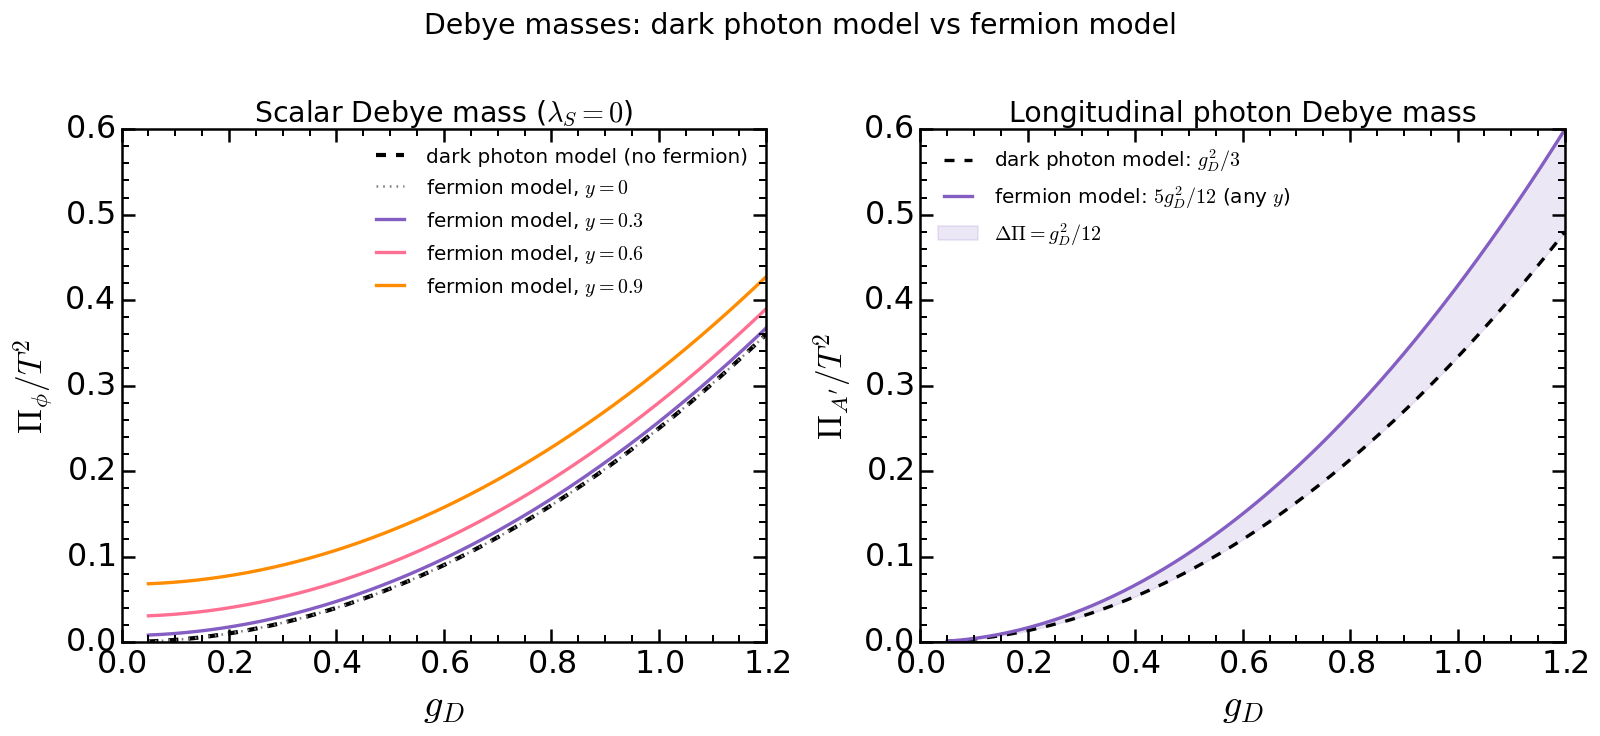

In [3]:
y_vals   = [0.0, 0.3, 0.6, 0.9]
colors_y = ['#222222', '#845ec2', '#ff6f91', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), dpi=120, facecolor='w')

# --- Left: scalar Debye mass ---
ax = axes[0]
# dark photon model: no fermion field at all
ax.plot(gD_arr, veff.VeffRGE.PiPhi(gD_arr, 1.0, ls_ref), lw=2.5, color='k', ls='--',
        label=r'dark photon model (no fermion)')
# fermion model with y=0: fermion exists but Yukawa switched off
ax.plot(gD_arr, veff_ferm.VeffRGE_fermion.PiPhi(gD_arr, 0.0, 1.0, ls_ref), lw=1.5, color='gray', ls=':',
        label=r'fermion model, $y=0$')
# fermion model with y > 0
for y_v, c in zip(y_vals[1:], colors_y[1:]):
    ax.plot(gD_arr, veff_ferm.VeffRGE_fermion.PiPhi(gD_arr, y_v, 1.0, ls_ref), lw=2, color=c,
            label=fr'fermion model, $y={y_v}$')
ax.axhline(1.0, color='lightgray', ls=':', lw=1)
ax.legend(frameon=False, fontsize=12)
ps.apply_standard_formatting(ax,
    xlabel=r'$g_D$', ylabel=r'$\Pi_\phi / T^2$',
    title=r'Scalar Debye mass ($\lambda_S = 0$)',
    xlim=(0, 1.2), ylim=(0, 0.6))

# --- Right: longitudinal photon Debye mass ---
ax = axes[1]
ax.plot(gD_arr, veff.VeffRGE.PiAp(gD_arr, 1.0), lw=2, color='k', ls='--',
        label=r'dark photon model: $g_D^2/3$')
ax.plot(gD_arr, veff_ferm.VeffRGE_fermion.PiAp(gD_arr, 1.0), lw=2, color='#845ec2',
        label=r'fermion model: $5g_D^2/12$ (any $y$)')
ax.fill_between(gD_arr,
                veff.VeffRGE.PiAp(gD_arr, 1.0),
                veff_ferm.VeffRGE_fermion.PiAp(gD_arr, 1.0),
                alpha=0.15, color='#845ec2', label=r'$\Delta\Pi = g_D^2/12$')
ax.axhline(0, color='k', lw=1)
ax.legend(frameon=False, fontsize=12, loc='best')
ps.apply_standard_formatting(ax,
    xlabel=r'$g_D$', ylabel=r'$\Pi_{A^\prime} / T^2$',
    title=r'Longitudinal photon Debye mass',
    xlim=(0, 1.2), ylim=(0, 0.6))

plt.suptitle(r'Debye masses: dark photon model vs fermion model', fontsize=17, y=1.02)
plt.tight_layout()
plt.show()


In [4]:
gD_ref = 0.6
y_ref  = 0.3

PiPhi_nf = veff.VeffRGE.PiPhi(gD_ref, 1.0, ls_ref)
PiPhi_f  = veff_ferm.VeffRGE_fermion.PiPhi(gD_ref, y_ref, 1.0, ls_ref)
PiAp_nf  = veff.VeffRGE.PiAp(gD_ref, 1.0)
PiAp_f   = veff_ferm.VeffRGE_fermion.PiAp(gD_ref, 1.0)

print(f"Benchmark: gD = {gD_ref}, y = {y_ref}, lambdaS = {ls_ref}")
print()
print(f"  Pi_phi (no ferm.)  = {PiPhi_nf:.4f} T^2")
print(f"  Pi_phi (with ferm) = {PiPhi_f:.4f} T^2")
print(f"  Fermion adds       = {(PiPhi_f - PiPhi_nf)/PiPhi_nf * 100:.1f}% to Pi_phi")
print()
print(f"  Pi_Ap  (no ferm.)  = {PiAp_nf:.4f} T^2  [gD^2/3]")
print(f"  Pi_Ap  (with ferm) = {PiAp_f:.4f} T^2  [5*gD^2/12]")
print(f"  Fermion adds       = {(PiAp_f - PiAp_nf)/PiAp_nf * 100:.1f}% to Pi_Ap  (= 1/4 of the no-fermion value)")
print()
print("  Transverse A' modes: Pi_T = 0  (no Debye screening)")
print(f"  Magnetic mass estimate: m_mag ~ gD^2 T / (4pi) = {gD_ref**2 / (4*np.pi):.4f} T")

Benchmark: gD = 0.6, y = 0.3, lambdaS = 0.0

  Pi_phi (no ferm.)  = 0.0900 T^2
  Pi_phi (with ferm) = 0.0975 T^2
  Fermion adds       = 8.3% to Pi_phi

  Pi_Ap  (no ferm.)  = 0.1200 T^2  [gD^2/3]
  Pi_Ap  (with ferm) = 0.1500 T^2  [5*gD^2/12]
  Fermion adds       = 25.0% to Pi_Ap  (= 1/4 of the no-fermion value)

  Transverse A' modes: Pi_T = 0  (no Debye screening)
  Magnetic mass estimate: m_mag ~ gD^2 T / (4pi) = 0.0286 T


---
## 3. High-$T$ Expansion Validity: $m_i(S)/T \ll 1$

The high-$T$ expansion of $J_B(m^2/T^2)$ and $J_F(m^2/T^2)$ in powers of $m/T$ is controlled by
$$x_i \equiv m_i^2(S)/T^2.$$
The expansion breaks down when $x_i \gtrsim 1$, i.e., when the particle is Boltzmann suppressed.

For a first-order transition at $T_*$ with VEV $v_* \sim T_*/g_D$ (Coleman-Weinberg mechanism):

| Species | $m^2(v_*)/T_*^2$ |
|---|---|
| Scalar $\phi$ | $\sim \lambda_S/g_D^2$ (small near CW) |
| Goldstone $\sigma$ | $\sim 0$ (massless in CW limit) |
| Dark photon $A'$ (all 3) | $g_D^2 v_*^2/T_*^2 \sim 1$ |
| Fermion $\chi$ | $y^2 v_*^2/(2T_*^2) \sim y^2/(2 g_D^2)$ |

**Key point:** At the true vacuum $v_* \sim T_*/g_D$, the fermion mass ratio is
$$\frac{m_\chi(v_*)}{T_*} = \frac{y v_*}{\sqrt{2}\, T_*} \sim \frac{y}{\sqrt{2}\, g_D}.$$
If $y \gtrsim g_D$, the high-$T$ expansion for the fermion breaks down **at the true vacuum** — the full $J_F$ integral should be used there.

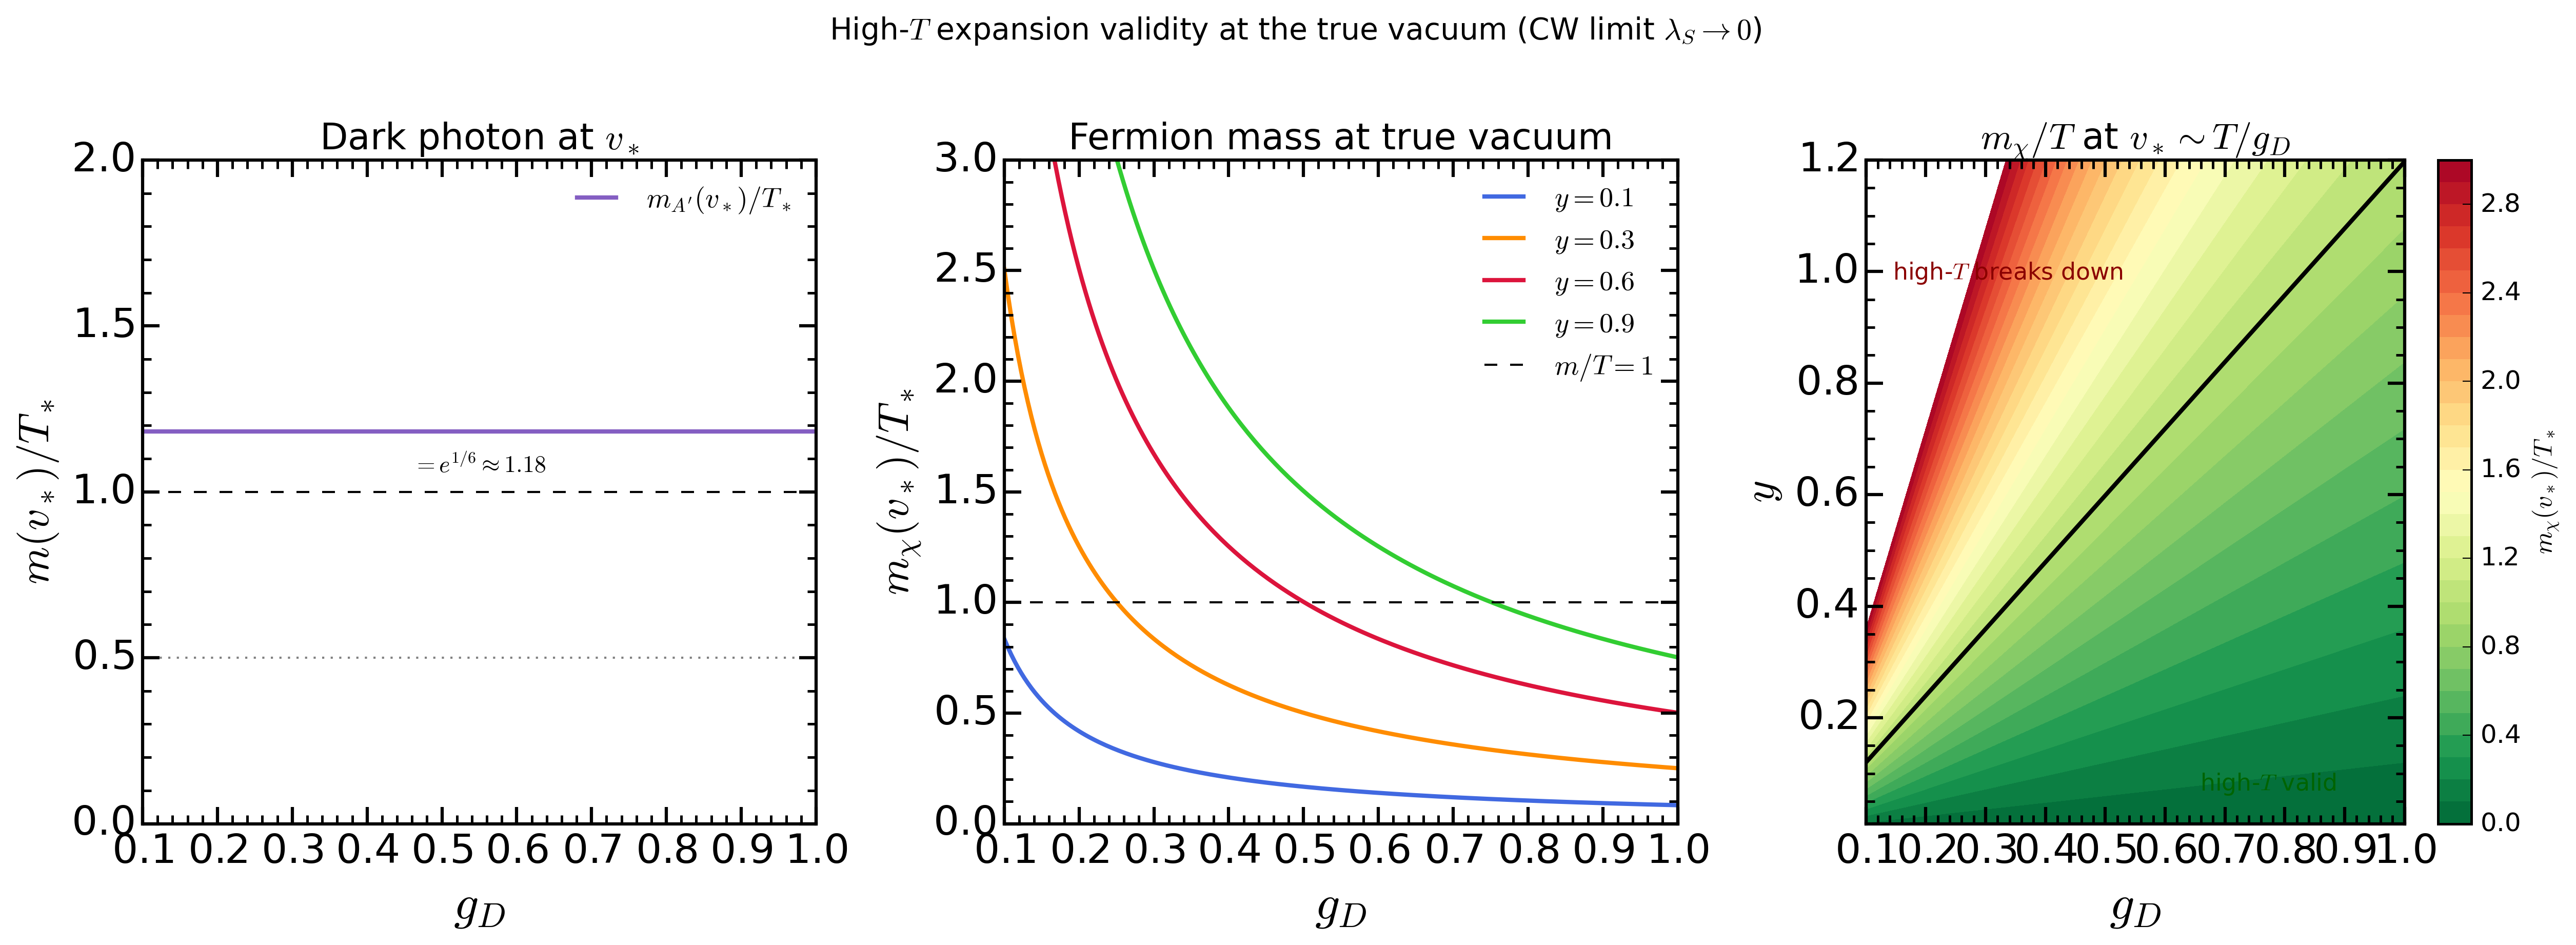

For gD=0.6: fermion high-T breakdown when y > 0.72


In [5]:
gD_vals     = np.linspace(0.1, 1.0, 200)
y_vals_scan = [0.1, 0.3, 0.6, 0.9]
colors_y2   = ['royalblue', 'darkorange', 'crimson', 'limegreen']

def vstar_over_T(gD):
    return np.exp(1.0/6.0) / gD

fig, axes = plt.subplots(1, 3, figsize=(17, 6), dpi=300, facecolor='w')

# --- Panel 0: m_Ap(v*)/T ---
ax = axes[0]
ax.plot(gD_vals, gD_vals * vstar_over_T(gD_vals), lw=2, color='#845ec2',
        label=r'$m_{A^\prime}(v_*)/T_*$')
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.text(0.5, 0.53, r'$= e^{1/6} \approx 1.18$', fontsize=11,
        transform=ax.transAxes, ha='center')
ax.legend(frameon=False, fontsize=13)
ps.apply_standard_formatting(ax,
    xlabel=r'$g_D$', ylabel=r'$m(v_*)/T_*$', ylim=(0, 2), xlim=(0.1, 1.0),
    title=r'Dark photon at $v_*$')

# --- Panel 1: m_chi(v*)/T ---
ax = axes[1]
for y_v, c in zip(y_vals_scan, colors_y2):
    ax.plot(gD_vals, y_v * vstar_over_T(gD_vals) / np.sqrt(2), lw=2, color=c,
            label=fr'$y={y_v}$')
ax.axhline(1.0, color='k', ls='--', lw=1, label=r'$m/T=1$')
ax.legend(frameon=False, fontsize=13)
ps.apply_standard_formatting(ax,
    xlabel=r'$g_D$', ylabel=r'$m_\chi(v_*)/T_*$', ylim=(0, 3),
    title=r'Fermion mass at true vacuum')

# --- Panel 2: 2D map m_chi/T in (gD, y) space ---
ax = axes[2]
GD, Y = np.meshgrid(gD_vals, np.linspace(0.01, 1.2, 200))
Mchi_map = Y * vstar_over_T(GD) / np.sqrt(2)
cf = ax.contourf(GD, Y, Mchi_map, levels=np.linspace(0, 3, 31), cmap='RdYlGn_r')
ax.contour(GD, Y, Mchi_map, levels=[1.0], colors='k', linewidths=2)
ax.text(0.62, 0.05, r'high-$T$ valid',       fontsize=11, color='darkgreen', transform=ax.transAxes)
ax.text(0.05, 0.82, r'high-$T$ breaks down', fontsize=11, color='darkred',   transform=ax.transAxes)
plt.colorbar(cf, ax=ax, label=r'$m_\chi(v_*)/T_*$')
ps.apply_standard_formatting(ax,
    xlabel=r'$g_D$', ylabel=r'$y$',
    title=r'$m_\chi/T$ at $v_* \sim T/g_D$')

plt.suptitle(r'High-$T$ expansion validity at the true vacuum (CW limit $\lambda_S \to 0$)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"For gD=0.6: fermion high-T breakdown when y > {0.6*np.sqrt(2)*np.exp(-1/6):.2f}")

---
## 4. Power Counting: Relative Size of Potential Contributions

At the FOPT scale $S \sim v_*$, $T \sim T_*$, the various contributions to $V_{\rm eff}$ scale as:

$$V_{\rm tree} \sim \lambda_S v^4 \quad (\sim 0 \text{ in CW limit})$$
$$V_{\rm CW} \sim \frac{g_D^4}{64\pi^2} v^4 \log(g_D)$$
$$V_T^{(2)} \sim \frac{g_D^2}{12} T^2 v^2 \quad (\text{Debye term})$$
$$V_{\rm daisy} \sim -\frac{T}{12\pi} (m_D^2)^{3/2} \sim -\frac{g_D^3}{12\pi} T^4$$

Near the CW mechanism ($\lambda_S \approx 0$, $v_* \sim T_*/g_D$), using $v^4 \sim T^4/g_D^4$:

| Term | Scale (at $v_*$) | Relative to $V_{\rm CW}$ |
|---|---|---|
| $V_{\rm CW}$ | $T^4/(64\pi^2)$ | 1 |
| $V_T^{(2)}$ (Debye) | $T^4/12$ | $16\pi^2/3 \approx 50$ |
| $V_{\rm daisy}$ | $g_D^3 T^4/(12\pi)$ | $\sim 16\pi g_D^3 \lesssim 1$ |

The thermal $T^2$ piece dominates: it drives the symmetry restoration above $T_c$.

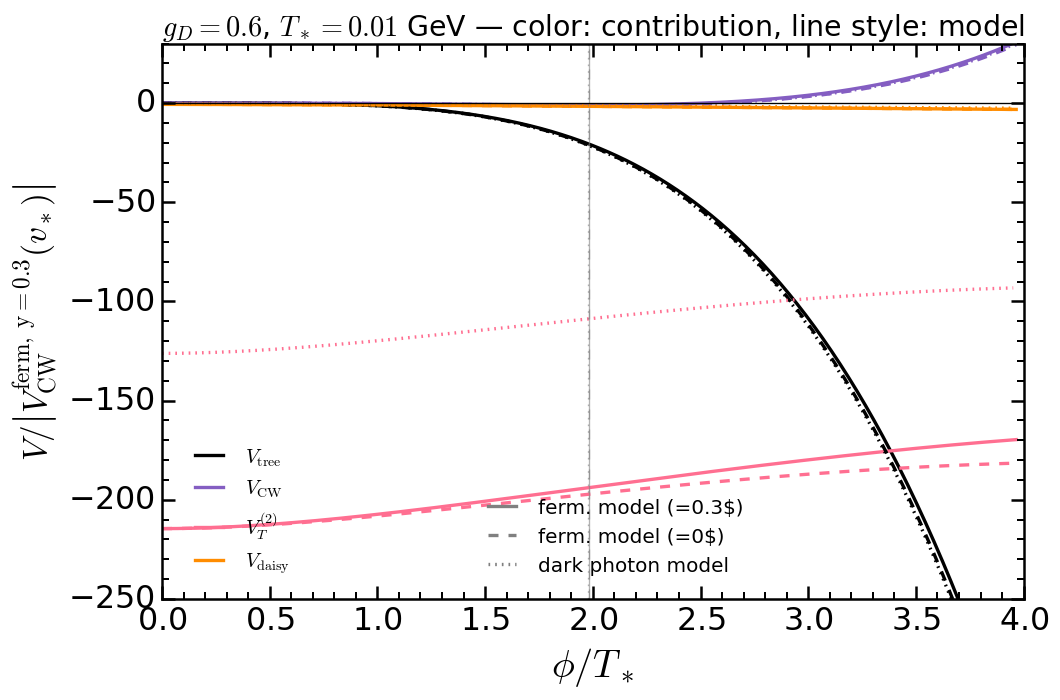

At v*  (norm = |V_CW^ferm_y=0.3(v*)|):
  Model                       V_CW       V_T     V_daisy    v*/T
  ferm. y=0.3               -1.000  -193.756      -1.645    1.98
  ferm. y=0                 -1.158  -197.112      -1.645    1.98
  dark photon               -1.157  -108.869      -1.314    1.98


In [9]:
from matplotlib.lines import Line2D

gD0_bm   = 0.6
y0_bm    = 0.3
ls0_bm   = 0.0
T_bm     = 0.01
scale_bm = 1.0
mu_bm    = scale_bm * T_bm

colors_pc = {'tree': 'k', 'cw': '#845ec2', 'vt': '#ff6f91', 'daisy': 'darkorange'}

# --- fermion model, y=0.3 (solid) ---
veff_f = veff_ferm.VeffRGE_fermion(y0=y0_bm)
gD_r, ls_r, mS2_r, y_r = rge_ferm.RGESolver_fermion.run_params(mu_bm, gD0_bm, ls0_bm, 0.0, y0_bm)
v_star = np.exp(1.0/6.0) / gD_r * T_bm
S_f    = np.linspace(0, 2*v_star, 500)
Vtree_f  = veff_f.Vtree(S_f, ls_r, mS2_r)
VCW_f    = veff_f.Vcw(S_f, mu_bm, gD_r, y_r, ls_r, mS2_r)
VT_f     = veff_f._VT_highT(S_f, T_bm, gD_r, y_r, ls_r, mS2_r)
Vdaisy_f = veff_f.Vdaisy(S_f, T_bm, gD_r, y_r, ls_r, mS2_r)
i_v      = np.argmin(np.abs(S_f - v_star))
norm     = np.abs(VCW_f[i_v]) or 1.0

# --- fermion model, y=0 (dashed) ---
veff_f0 = veff_ferm.VeffRGE_fermion(y0=0.0)
gD_r0, ls_r0, mS2_r0, y_r0 = rge_ferm.RGESolver_fermion.run_params(mu_bm, gD0_bm, ls0_bm, 0.0, 0.0)
v_star0  = np.exp(1.0/6.0) / gD_r0 * T_bm
S_f0     = np.linspace(0, 2*v_star0, 500)
Vtree_f0  = veff_f0.Vtree(S_f0, ls_r0, mS2_r0)
VCW_f0    = veff_f0.Vcw(S_f0, mu_bm, gD_r0, y_r0, ls_r0, mS2_r0)
VT_f0     = veff_f0._VT_highT(S_f0, T_bm, gD_r0, y_r0, ls_r0, mS2_r0)
Vdaisy_f0 = veff_f0.Vdaisy(S_f0, T_bm, gD_r0, y_r0, ls_r0, mS2_r0)
i_v0      = np.argmin(np.abs(S_f0 - v_star0))

# --- dark photon model (dotted) ---
veff_nf = veff.VeffRGE()
gD_r_nf, ls_r_nf, mS_r_nf = rge.RGESolver.run_params(mu_bm, gD0_bm, ls0_bm, 0.0)
v_star_nf = np.exp(1.0/6.0) / gD_r_nf * T_bm
S_nf      = np.linspace(0, 2*v_star_nf, 500)
Vtree_nf  = veff_nf.Vtree(S_nf, ls_r_nf, mS_r_nf)
VCW_nf    = veff_nf.Vcw(S_nf, mu_bm, gD_r_nf, ls_r_nf, mS_r_nf)
VT_nf     = veff_nf.V_highT(S_nf, T_bm, gD_r_nf, ls_r_nf, mS_r_nf)
Vdaisy_nf = veff_nf.Vdaisy(S_nf, T_bm, gD_r_nf, ls_r_nf, mS_r_nf)
i_v_nf    = np.argmin(np.abs(S_nf - v_star_nf))

# --- plot ---
fig, ax = new_figure(figsize=(9, 6), dpi=120, facecolor='w')

for S_p, Vt, Vc, VT, Vd, vs, ls in [
    (S_f,   Vtree_f,  VCW_f,  VT_f,  Vdaisy_f,  v_star,    '-'),
    (S_f0,  Vtree_f0, VCW_f0, VT_f0, Vdaisy_f0, v_star0,   '--'),
    (S_nf,  Vtree_nf, VCW_nf, VT_nf, Vdaisy_nf, v_star_nf, ':'),
]:
    ax.plot(S_p/T_bm, Vt / norm, lw=2, color=colors_pc['tree'],  ls=ls)
    ax.plot(S_p/T_bm, Vc / norm, lw=2, color=colors_pc['cw'],    ls=ls)
    ax.plot(S_p/T_bm, VT / norm, lw=2, color=colors_pc['vt'],    ls=ls)
    ax.plot(S_p/T_bm, Vd / norm, lw=2, color=colors_pc['daisy'], ls=ls)
    ax.axvline(vs/T_bm, color='gray', ls=ls, lw=0.8, alpha=0.6)

ax.axhline(0, color='k', lw=0.8)

# compact legend: color = contribution, line style = model
legend_contribs = [
    Line2D([0],[0], color=colors_pc['tree'],  lw=2, label=r'$V_{\rm tree}$'),
    Line2D([0],[0], color=colors_pc['cw'],    lw=2, label=r'$V_{\rm CW}$'),
    Line2D([0],[0], color=colors_pc['vt'],    lw=2, label=r'$V_T^{(2)}$'),
    Line2D([0],[0], color=colors_pc['daisy'], lw=2, label=r'$V_{\rm daisy}$'),
]
legend_models = [
    Line2D([0],[0], color='gray', lw=2, ls='-',  label=fr'ferm. model (={y0_bm}$)'),
    Line2D([0],[0], color='gray', lw=2, ls='--', label=r'ferm. model (=0$)'),
    Line2D([0],[0], color='gray', lw=2, ls=':',  label=r'dark photon model'),
]
leg1 = ax.legend(handles=legend_contribs, frameon=False, fontsize=12,
                 loc='lower left', bbox_to_anchor=(0.01, 0.01))
ax.add_artist(leg1)
ax.legend(handles=legend_models, frameon=False, fontsize=12,
          loc='lower left', bbox_to_anchor=(0.35, 0.01))

ps.apply_standard_formatting(
    ax,
    xlabel=r'$\phi / T_*$',
    ylabel=r'$V / \left|V_{\rm CW}^{\rm ferm,\;y=0.3}(v_*)\right|$',
    title=fr'$g_D={gD0_bm}$, $T_*={T_bm}$ GeV — color: contribution, line style: model',
    ylim=(-250, 30),
)
plt.tight_layout()
plt.show()

print(f"At v*  (norm = |V_CW^ferm_y=0.3(v*)|):")
print(f"  {'Model':22s}  {'V_CW':>8}  {'V_T':>8}  {'V_daisy':>10}  {'v*/T':>6}")
print(f"  {'ferm. y=0.3':22s}  {VCW_f[i_v]/norm:>8.3f}  {VT_f[i_v]/norm:>8.3f}  {Vdaisy_f[i_v]/norm:>10.3f}  {v_star/T_bm:>6.2f}")
print(f"  {'ferm. y=0':22s}  {VCW_f0[i_v0]/norm:>8.3f}  {VT_f0[i_v0]/norm:>8.3f}  {Vdaisy_f0[i_v0]/norm:>10.3f}  {v_star0/T_bm:>6.2f}")
print(f"  {'dark photon':22s}  {VCW_nf[i_v_nf]/norm:>8.3f}  {VT_nf[i_v_nf]/norm:>8.3f}  {Vdaisy_nf[i_v_nf]/norm:>10.3f}  {v_star_nf/T_bm:>6.2f}")


---
## 5. Fermion Effect on Power Counting

The fermion modifies the power counting in two ways:

### 5a. Modified Debye masses (already seen above)
- Scalar Debye mass gets $+y^2/12 \cdot T^2$: shifts the symmetry-restoration temperature
- Photon Debye mass goes from $g_D^2/3$ to $5g_D^2/12$ (+25%): mildly enhances the daisy contribution

### 5b. Fermion loop in CW and $V_T$
The fermion contributes with a **negative sign** to $V_{\rm CW}$ and with a different sign to $V_T$:
$$\Delta V_{\rm CW}^{\rm ferm} = -4 \cdot \frac{m_\chi^4(S)}{64\pi^2}\left(\log\frac{m_\chi^2}{\mu^2} - \frac{3}{2}\right) = -\frac{y^4 S^4}{16 \times 64\pi^2}\left(\log\frac{y^2 S^2}{2\mu^2} - \frac{3}{2}\right)$$
The factor $-4$ comes from $2 \times 2$ (2 spins $\times$ particle+antiparticle).

$$\Delta V_T^{\rm ferm} = -\frac{4 T^4}{2\pi^2} J_F\!\left(\frac{m_\chi^2}{T^2}\right)$$
with $J_F(0) = 7\pi^4/360 > 0$, so this contributes **negatively** (fermions suppress $V_T$).

### 5c. RGE running — doubled $\beta_{g_D^2}$
The fermion doubles the one-loop coefficient of $\beta_{g_D^2}$:
$$\beta_{g_D^2}^{\rm no\,ferm} = \frac{g_D^4}{24\pi^2}, \qquad \beta_{g_D^2}^{\rm ferm} = \frac{g_D^4}{12\pi^2}.$$
This means **Landau poles** are reached at a lower scale with the fermion.

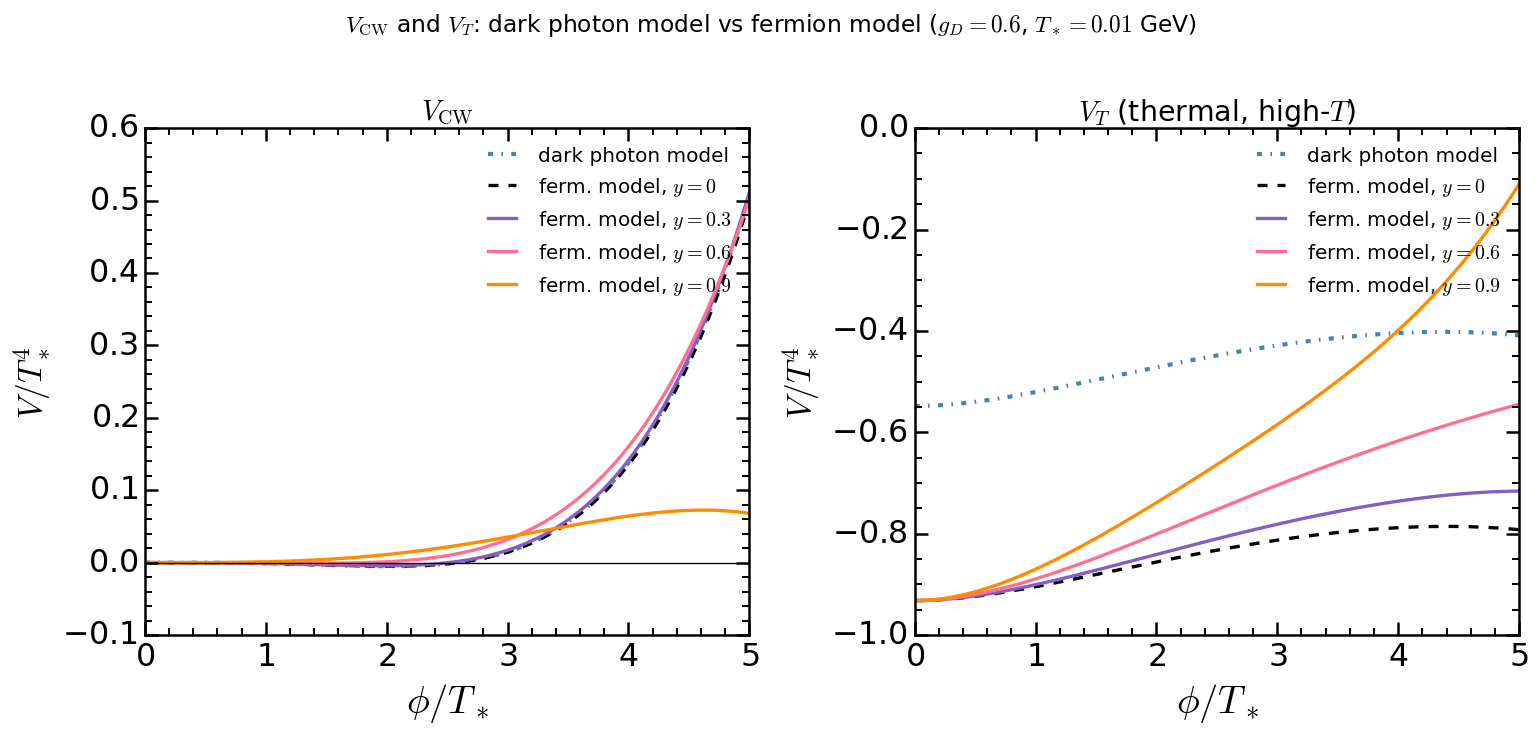

In [10]:
gD0_bm2 = 0.6
ls0_bm2 = 0.0
T_bm2   = 0.01
mu_bm2  = T_bm2

y_list  = [0.0, 0.3, 0.6, 0.9]
c_list  = ['k', '#845ec2', '#ff6f91', 'darkorange']

S_plot = np.linspace(0, 3*T_bm2/gD0_bm2, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=120, facecolor='w')

# --- dark photon model (no fermion field at all) ---
veff_nf = veff.VeffRGE()
gD_r_nf, ls_r_nf, mS_r_nf = rge.RGESolver.run_params(mu_bm2, gD0_bm2, ls0_bm2, 0.0)
VCW_nf = veff_nf.Vcw(S_plot, mu_bm2, gD_r_nf, ls_r_nf, mS_r_nf)
VT_nf  = veff_nf.V_highT(S_plot, T_bm2, gD_r_nf, ls_r_nf, mS_r_nf)
axes[0].plot(S_plot/T_bm2, VCW_nf / T_bm2**4, lw=2.5, color='steelblue', ls='-.', label=r'dark photon model')
axes[1].plot(S_plot/T_bm2, VT_nf  / T_bm2**4, lw=2.5, color='steelblue', ls='-.', label=r'dark photon model')

# --- fermion model at various y ---
for y_i, c_i in zip(y_list, c_list):
    gD_r2, ls_r2, mS2_r2, y_r2 = rge_ferm.RGESolver_fermion.run_params(mu_bm2, gD0_bm2, ls0_bm2, 0.0, y_i)
    vf_i = veff_ferm.VeffRGE_fermion(y0=y_i)

    VCW_i = vf_i.Vcw(S_plot, mu_bm2, gD_r2, y_r2, ls_r2, mS2_r2)
    VT_i  = vf_i._VT_highT(S_plot, T_bm2, gD_r2, y_r2, ls_r2, mS2_r2)

    label    = fr'ferm. model, $y={y_i}$' if y_i > 0 else r'ferm. model, $y=0$'
    ls_style = '--' if y_i == 0.0 else '-'

    axes[0].plot(S_plot/T_bm2, VCW_i / T_bm2**4, lw=2, color=c_i, ls=ls_style, label=label)
    axes[1].plot(S_plot/T_bm2, VT_i  / T_bm2**4, lw=2, color=c_i, ls=ls_style, label=label)

for ax, title in zip(axes, [r'$V_{\rm CW}$', r'$V_T$ (thermal, high-$T$)']):
    ax.axhline(0, color='k', lw=0.8)
    ax.legend(frameon=False, fontsize=12)
    ps.apply_standard_formatting(ax,
        xlabel=r'$\phi/T_*$', ylabel=r'$V / T_*^4$', title=title)

plt.suptitle(fr'$V_{{\rm CW}}$ and $V_T$: dark photon model vs fermion model ($g_D={gD0_bm2}$, $T_*={T_bm2}$ GeV)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


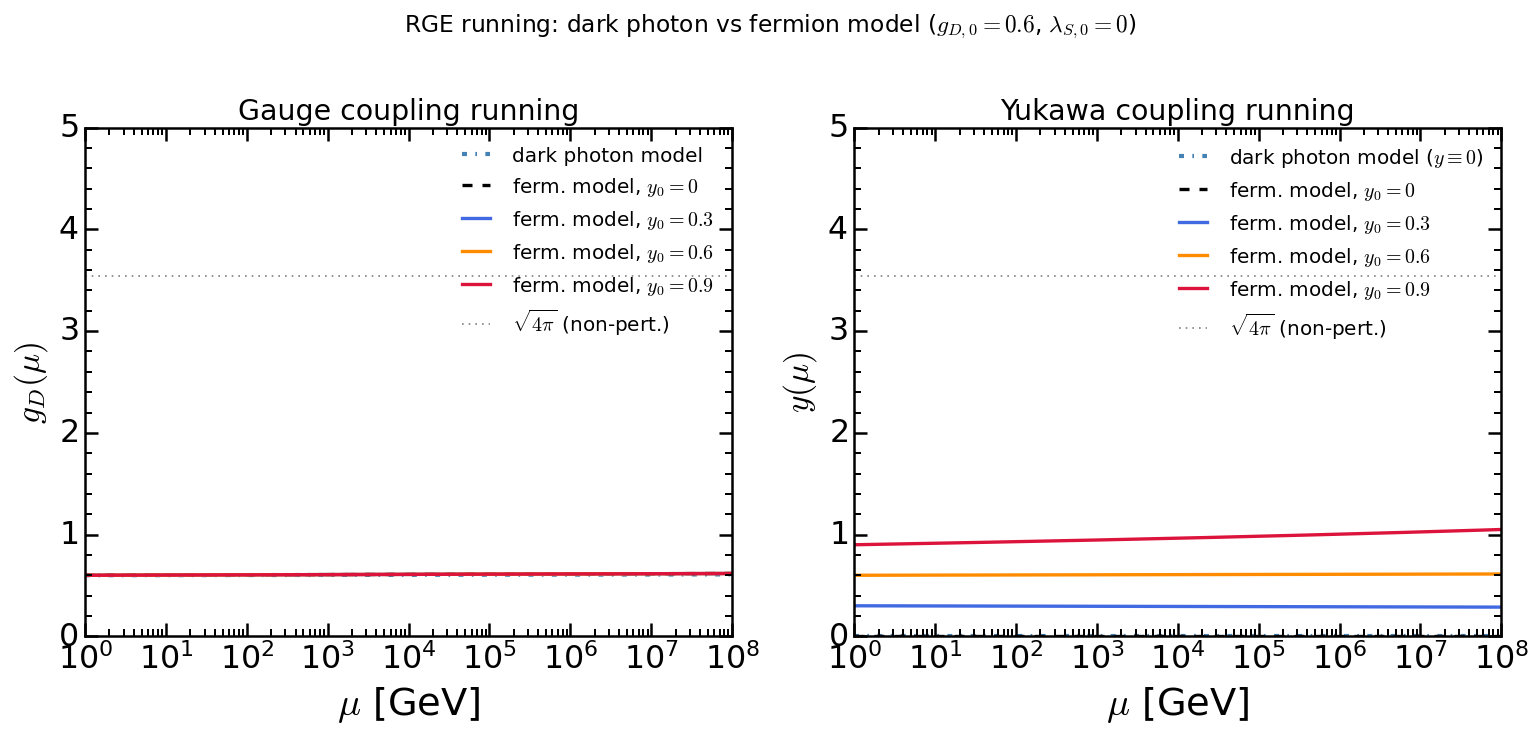

Analytic Landau pole estimate (1-loop):
  dark photon model:  mu_LP ~ exp(12pi^2 / gD0^2) = 7.54e+142 GeV
  ferm. model, y0=0:  mu_LP ~ exp( 6pi^2 / gD0^2) = 2.75e+71 GeV

  --> Even with y=0, the fermion model hits the Landau pole earlier:
      the fermion loop doubles beta_gD2 regardless of y (U(1)_D charge != 0)


In [ ]:
gD0_lp    = 0.6
ls0_lp    = 0.0
y0_list   = [0.0, 0.3, 0.6, 0.9]
colors_lp = ['k', 'royalblue', 'darkorange', 'crimson']

mu_range = np.logspace(0, 8, 600)
logmu    = np.log(mu_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=120, facecolor='w')

# --- dark photon model (no fermion field: beta_gD2 = gD^4/24pi^2) ---
sol_nf = solve_ivp(
    rge.RGESolver._rhs,
    (np.log(1.0), np.log(1e8)),
    [gD0_lp**2, ls0_lp, 0.0],
    dense_output=True, max_step=0.05, rtol=1e-9, atol=1e-11,
)
gD2_nf = np.where(sol_nf.sol(logmu)[0] > 16*np.pi**2, np.nan, sol_nf.sol(logmu)[0])
axes[0].plot(mu_range, np.sqrt(np.abs(gD2_nf)), lw=2.5, color='steelblue', ls='-.',
             label=r'dark photon model')
axes[1].axhline(0, color='steelblue', ls='-.', lw=2.5, label=r'dark photon model ($y \equiv 0$)')

# --- fermion model (beta_gD2 = gD^4/12pi^2 even for y=0) ---
for y0_i, c_i in zip(y0_list, colors_lp):
    sol_i = solve_ivp(
        rge_ferm.RGESolver_fermion._rhs,
        (np.log(1.0), np.log(1e8)),
        [gD0_lp**2, ls0_lp, 0.0, y0_i],
        dense_output=True, max_step=0.05, rtol=1e-9, atol=1e-11,
    )
    gD2_i   = np.where(sol_i.sol(logmu)[0] > 16*np.pi**2, np.nan, sol_i.sol(logmu)[0])
    y_run_i = sol_i.sol(logmu)[3]

    label = fr'ferm. model, $y_0={y0_i}$' if y0_i > 0 else r'ferm. model, $y_0=0$'
    ls_s  = '--' if y0_i == 0.0 else '-'

    axes[0].plot(mu_range, np.sqrt(np.abs(gD2_i)), lw=2, color=c_i, ls=ls_s, label=label)
    axes[1].plot(mu_range, y_run_i,                lw=2, color=c_i, ls=ls_s, label=label)

for ax, ylabel, title in zip(
        axes,
        [r'$g_D(\mu)$', r'$y(\mu)$'],
        [r'Gauge coupling running', r'Yukawa coupling running']):
    ax.axhline(np.sqrt(4*np.pi), color='gray', ls=':', lw=1, label=r'$\sqrt{4\pi}$ (non-pert.)')
    ax.legend(frameon=False, fontsize=12)
    ps.apply_standard_formatting(ax, xlog=True,
        xlabel=r'$\mu$ [GeV]', ylabel=ylabel, title=title,
        xlim=(1, 1e8), ylim=(0, 5))

plt.suptitle(fr'RGE running: dark photon vs fermion model ($g_{{D,0}}={gD0_lp}$, $\lambda_{{S,0}}=0$)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Analytic Landau pole estimate (1-loop):")
print(f"  dark photon model:  mu_LP ~ exp(12pi^2 / gD0^2) = {np.exp(12*np.pi**2/gD0_lp**2):.2e} GeV")
print(f"  ferm. model, y0=0:  mu_LP ~ exp( 6pi^2 / gD0^2) = {np.exp(6*np.pi**2/gD0_lp**2):.2e} GeV")
print()
print("  --> Even with y=0, the fermion model hits the Landau pole earlier:")
print("      the fermion loop doubles beta_gD2 regardless of y (U(1)_D charge != 0)")


---
## 6. EFT Validity Summary: Parameter Space Scan

We combine three criteria for the EFT to be controlled:

1. **Perturbativity** of the couplings at the transition scale: $g_D(T_*) < 1$, $y(T_*) < 1$
2. **High-$T$ expansion** valid at true vacuum: $m_\chi(v_*)/T_* = y/(\sqrt{2}\, g_D) < 1$
3. **Daisy resummation controlled**: $V_{\rm daisy}/V_{\rm CW} \sim g_D^3/(g_D^4/\pi) = \pi/g_D \lesssim 1$  
   (this is parametrically satisfied only for $g_D \gtrsim \pi$, so daisy is always $\mathcal{O}(1)$ in the CW mechanism — this is the expected strong-coupling nature of the FOPT)


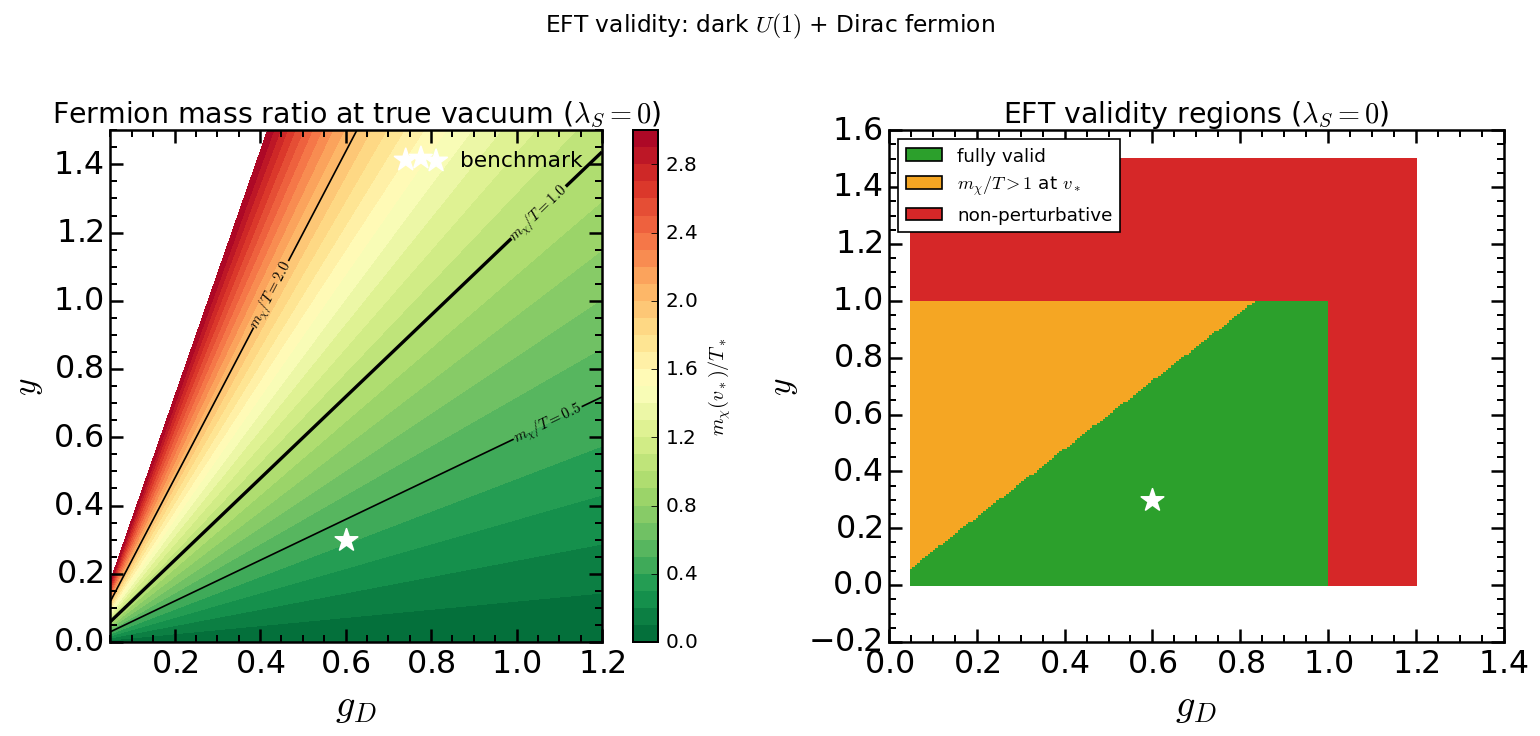


Benchmark (gD=0.6, y=0.3):
  Pi_phi/T^2  = 0.098
  Pi_Ap_L/T^2 = 0.150  (longitudinal only; Pi_T = 0)
  m_chi/T     = 0.42  OK
  m_Ap/T      = 1.18  (= e^{1/6}, always > 1 in CW mechanism)


In [ ]:
gD_scan = np.linspace(0.05, 1.2, 200)
y_scan  = np.linspace(0.0,  1.5, 200)
GD2D, Y2D = np.meshgrid(gD_scan, y_scan)

mchi_ratio = Y2D / (np.sqrt(2) * GD2D) * np.exp(1.0/6.0)
crit1 = mchi_ratio < 1.0
crit2 = GD2D < 1.0
crit3 = Y2D  < 1.0
PiPhi_2D = veff_ferm.VeffRGE_fermion.PiPhi(GD2D, Y2D, 1.0, 0.0)
crit4 = PiPhi_2D < 1.0
all_valid = crit1 & crit2 & crit3 & crit4

fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=120, facecolor='w')

# --- Left: m_chi/T map ---
ax = axes[0]
cf  = ax.contourf(GD2D, Y2D, mchi_ratio, levels=np.linspace(0, 3, 31), cmap='RdYlGn_r')
cs1 = ax.contour(GD2D, Y2D, mchi_ratio, levels=[0.5, 1.0, 2.0], colors='k', linewidths=[1, 2, 1])
ax.clabel(cs1, fmt=r'$m_\chi/T=%.1f$', fontsize=9)
plt.colorbar(cf, ax=ax, label=r'$m_\chi(v_*)/T_*$')
ax.scatter([0.6], [0.3], marker='*', s=200, color='white', zorder=5, label='benchmark')
ax.legend(frameon=False, fontsize=13)
ps.apply_standard_formatting(ax,
    xlabel=r'$g_D$', ylabel=r'$y$',
    title=r'Fermion mass ratio at true vacuum ($\lambda_S=0$)')

# --- Right: combined validity regions ---
ax = axes[1]
validity_map = np.zeros_like(GD2D)
validity_map[crit2 & crit3 & crit4 & ~crit1] = 1
validity_map[all_valid]                         = 2

cmap_v = plt.matplotlib.colors.ListedColormap(['#d62728', '#f5a623', '#2ca02c'])
norm_v = plt.matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_v.N)
ax.pcolormesh(GD2D, Y2D, validity_map, cmap=cmap_v, norm=norm_v, shading='auto')
ax.scatter([0.6], [0.3], marker='*', s=200, color='white', zorder=5)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ca02c', label='fully valid'),
    Patch(facecolor='#f5a623', label=r'$m_\chi/T > 1$ at $v_*$'),
    Patch(facecolor='#d62728', label=r'non-perturbative'),
], frameon=True, fontsize=11, loc='upper left')
ps.apply_standard_formatting(ax,
    xlabel=r'$g_D$', ylabel=r'$y$',
    title=r'EFT validity regions ($\lambda_S=0$)')

plt.suptitle('EFT validity: dark $U(1)$ + Dirac fermion', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

g, y = 0.6, 0.3
print(f"\nBenchmark (gD={g}, y={y}):")
print(f"  Pi_phi/T^2  = {veff_ferm.VeffRGE_fermion.PiPhi(g, y, 1.0, 0.0):.3f}")
print(f"  Pi_Ap_L/T^2 = {veff_ferm.VeffRGE_fermion.PiAp(g, 1.0):.3f}  (longitudinal only; Pi_T = 0)")
print(f"  m_chi/T     = {y/(np.sqrt(2)*g)*np.exp(1/6):.2f}  {'OK' if y/(np.sqrt(2)*g)*np.exp(1/6)<1 else 'WARNING'}")
print(f"  m_Ap/T      = {np.exp(1/6):.2f}  (= e^{{1/6}}, always > 1 in CW mechanism)")

---
## 7. Summary and Caveats

### What the fermion does

| Effect | With fermion | Without fermion | Impact |
|---|---|---|---|
| $\Pi_\phi/T^2$ | $\lambda/3 + g^2/4 + y^2/12$ | $\lambda/3 + g^2/4$ | raises symmetry restoration $T_c$ |
| $\Pi_{A',L}/T^2$ | $5g^2/12$ | $g^2/3$ | +25%, mild |
| $\Pi_{A',T}$ | **0** | **0** | transverse always unscreened |
| $\beta_{g_D^2}$ | $g_D^4/(12\pi^2)$ | $g_D^4/(24\pi^2)$ | Landau pole at lower scale |
| $V_{\rm CW}$ | minus fermion loop | — | reduces $|V_{\rm CW}|$, affects VEV |
| $V_T$ | minus $4J_F$ | — | modifies free energy |

### Key caveats about the current treatment

1. **Transverse modes in daisy:** The code correctly applies `fd_Ap` to only 1 longitudinal mode in `Vdaisy`. The 2 transverse modes are fully included in `VCW` and `VT` with their field-dependent mass $m_{A'}(S) = g_D S$ only.

2. **Fermion at the true vacuum:** The ratio $m_\chi(v_*)/T_* = y e^{1/6}/(\sqrt{2}\, g_D)$ can exceed 1 for $y \gtrsim g_D$. In that region the high-$T$ expansion for $J_F$ overestimates the fermion thermal contribution — the full numerical $J_F$ would give Boltzmann suppression instead.

3. **Photon at the true vacuum:** Similarly $m_{A'}(v_*)/T_* = e^{1/6} \approx 1.18$ always, meaning the dark photon is **never** truly light at the true vacuum in the CW mechanism — the high-$T$ expansion for $J_B(m_{A'}^2/T^2)$ has order-1 corrections.

4. **Magnetic mass:** The non-perturbative magnetic mass $m_{\rm mag} \sim g_D^2 T/(4\pi)$ of the transverse modes is not included. This is the standard limitation of perturbative daisy resummation and would require a 3D lattice calculation to address.

5. **DR approach vs Arnold-Espinosa:** A full dimensional reduction (DR) matching to a 3D EFT would systematically capture all $\mathcal{O}(g^4 T)$ contributions, at the cost of a more complex setup. The current high-$T$ expansion + Arnold-Espinosa daisy is accurate to $\mathcal{O}(g^3)$.

In [ ]:
header = f"{'gD':>5} {'y':>5} {'Pi_phi(nf)/T2':>14} {'Pi_phi(f)/T2':>13} {'Pi_ApL(nf)/T2':>14} {'Pi_ApL(f)/T2':>13} {'mchi(v*)/T':>11}"
print(header)
print("-" * len(header))

for gD_v in [0.3, 0.6, 0.9, 1.0]:
    for y_v in [0.0, 0.3, 0.6, 0.9]:
        PiPhi_nf = veff.VeffRGE.PiPhi(gD_v, 1.0, 0.0)
        PiPhi_f  = veff_ferm.VeffRGE_fermion.PiPhi(gD_v, y_v, 1.0, 0.0)
        PiAp_nf  = veff.VeffRGE.PiAp(gD_v, 1.0)
        PiAp_f   = veff_ferm.VeffRGE_fermion.PiAp(gD_v, 1.0)
        mchi     = y_v * np.exp(1/6) / (np.sqrt(2) * gD_v)
        print(f"{gD_v:>5.1f} {y_v:>5.1f} {PiPhi_nf:>14.4f} {PiPhi_f:>13.4f} {PiAp_nf:>14.4f} {PiAp_f:>13.4f} {mchi:>11.3f}")

   gD     y  Pi_phi(nf)/T2  Pi_phi(f)/T2  Pi_ApL(nf)/T2  Pi_ApL(f)/T2  mchi(v*)/T
---------------------------------------------------------------------------------
  0.3   0.0         0.0225        0.0225         0.0300        0.0375       0.000
  0.3   0.3         0.0225        0.0300         0.0300        0.0375       0.835
  0.3   0.6         0.0225        0.0525         0.0300        0.0375       1.671
  0.3   0.9         0.0225        0.0900         0.0300        0.0375       2.506
  0.6   0.0         0.0900        0.0900         0.1200        0.1500       0.000
  0.6   0.3         0.0900        0.0975         0.1200        0.1500       0.418
  0.6   0.6         0.0900        0.1200         0.1200        0.1500       0.835
  0.6   0.9         0.0900        0.1575         0.1200        0.1500       1.253
  0.9   0.0         0.2025        0.2025         0.2700        0.3375       0.000
  0.9   0.3         0.2025        0.2100         0.2700        0.3375       0.278
  0.9   0.6     